<a href="https://colab.research.google.com/github/iid7oomii/smell-ai/blob/main/smell_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install pyrfume without touching numpy
!pip install pyrfume --no-deps -q
!pip install pandas matplotlib scikit-learn requests -q

import pyrfume
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

print(f"numpy version: {np.__version__}")
print("All libraries ready")

numpy version: 1.26.4
All libraries ready


In [4]:
# Load molecules
molecules = pyrfume.load_data('leffingwell/molecules.csv')

# Correct filename is behavior.csv, not odors.csv
behavior = pyrfume.load_data('leffingwell/behavior.csv')

print(f"Total molecules: {len(molecules)}")
print(f"Total behavior rows: {len(behavior)}")
print("\nColumns:", behavior.columns.tolist())
print(behavior.head())

Total molecules: 3522
Total behavior rows: 3522

Columns: ['alcoholic', 'aldehydic', 'alliaceous', 'almond', 'animal', 'anisic', 'apple', 'apricot', 'aromatic', 'balsamic', 'banana', 'beefy', 'berry', 'black currant', 'brandy', 'bread', 'brothy', 'burnt', 'buttery', 'cabbage', 'camphoreous', 'caramellic', 'catty', 'chamomile', 'cheesy', 'cherry', 'chicken', 'chocolate', 'cinnamon', 'citrus', 'cocoa', 'coconut', 'coffee', 'cognac', 'coumarinic', 'creamy', 'cucumber', 'dairy', 'dry', 'earthy', 'ethereal', 'fatty', 'fermented', 'fishy', 'floral', 'fresh', 'fruity', 'garlic', 'gasoline', 'grape', 'grapefruit', 'grassy', 'green', 'hay', 'hazelnut', 'herbal', 'honey', 'horseradish', 'jasmine', 'ketonic', 'leafy', 'leathery', 'lemon', 'malty', 'meaty', 'medicinal', 'melon', 'metallic', 'milky', 'mint', 'mushroom', 'musk', 'musty', 'nutty', 'odorless', 'oily', 'onion', 'orange', 'orris', 'peach', 'pear', 'phenolic', 'pine', 'pineapple', 'plum', 'popcorn', 'potato', 'pungent', 'radish', 'ripe',

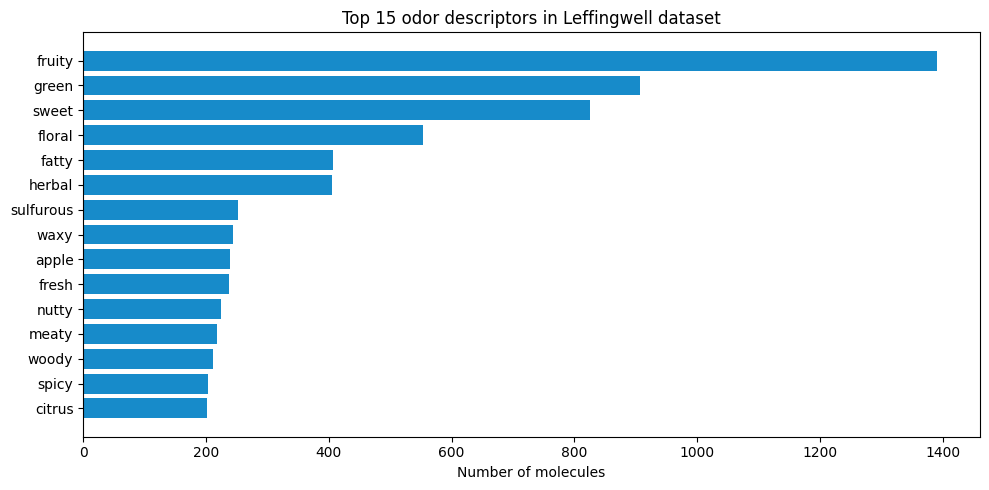

Top 5 odors: ['fruity', 'green', 'sweet', 'floral', 'fatty']


In [5]:
from collections import Counter

# Sum each column = how many molecules have this odor
odor_counts = behavior.sum().sort_values(ascending=False)

# Plot top 15
top15 = odor_counts.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15.index[::-1], top15.values[::-1], color='#178BCA')
plt.xlabel('Number of molecules')
plt.title('Top 15 odor descriptors in Leffingwell dataset')
plt.tight_layout()
plt.savefig('top_odors.png', dpi=150, bbox_inches='tight')
plt.show()

# Keep top 5 for classification
top5 = odor_counts.head(5).index.tolist()
print("Top 5 odors:", top5)

In [7]:
import warnings
warnings.filterwarnings('ignore')

# ── 1. Check what columns exist after merge ──────────────────────────────
print("Molecules columns:", molecules.columns.tolist())
print("Shape:", molecules.shape)

# ── 2. Merge — try index first, fallback to CID column ───────────────────
if 'CID' in molecules.columns:
    df = molecules.copy()
    df.index = df['CID']
else:
    df = molecules.copy()

df = df.merge(behavior, left_index=True, right_index=True, how='inner')
print(f"\nAfter merge shape: {df.shape}")

# ── 3. Assign primary label ───────────────────────────────────────────────
def primary_odor(row):
    for o in top5:
        if o in row.index and row[o] == 1:
            return o
    return None

df['label'] = df.apply(primary_odor, axis=1)
df = df.dropna(subset=['label'])
print(f"Labeled molecules: {len(df)}")
print(df['label'].value_counts())

# ── 4. Pick numeric feature columns automatically ─────────────────────────
# Exclude odor descriptor columns and label
odor_cols = behavior.columns.tolist()
exclude   = odor_cols + ['label', 'CID', 'IsomericSMILES', 'IUPACName',
                          'MolecularFormula', 'name', 'odor', 'odors']

numeric_cols = [c for c in df.columns
                if c not in exclude
                and df[c].dtype in ['float64','int64','float32','int32']]

print(f"\nNumeric feature columns found: {numeric_cols}")

# ── 5. Train model ────────────────────────────────────────────────────────
if len(numeric_cols) == 0:
    print("\nNo numeric features found — check column names above")
else:
    X = df[numeric_cols].fillna(0)
    y = LabelEncoder().fit_transform(df['label'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"\nModel accuracy: {acc:.1%}")
    available = numeric_cols

Molecules columns: ['MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name']
Shape: (3522, 4)

After merge shape: (3522, 117)
Labeled molecules: 2512
label
fruity    1391
green      457
sweet      389
fatty      156
floral     119
Name: count, dtype: int64

Numeric feature columns found: ['MolecularWeight']

Model accuracy: 61.0%


In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# ── 1. Extract molecular features from SMILES ─────────────────────────────
def extract_features(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return {
            'MolecularWeight'    : Descriptors.MolWt(mol),
            'LogP'               : Descriptors.MolLogP(mol),
            'NumHDonors'         : rdMolDescriptors.CalcNumHBD(mol),
            'NumHAcceptors'      : rdMolDescriptors.CalcNumHBA(mol),
            'NumRotatableBonds'  : rdMolDescriptors.CalcNumRotatableBonds(mol),
            'NumAromaticRings'   : rdMolDescriptors.CalcNumAromaticRings(mol),
            'NumAtoms'           : mol.GetNumAtoms(),
            'NumRings'           : rdMolDescriptors.CalcNumRings(mol),
            'TPSA'               : Descriptors.TPSA(mol),
            'FractionCSP3'       : rdMolDescriptors.CalcFractionCSP3(mol),
        }
    except:
        return None

print("Extracting features from SMILES...")
feat_list = df['IsomericSMILES'].apply(extract_features)
feat_df   = pd.DataFrame(feat_list.tolist(), index=df.index)
df2       = pd.concat([df[['label']], feat_df], axis=1).dropna()

print(f"Molecules after feature extraction: {len(df2)}")
print(f"Features: {feat_df.columns.tolist()}")

# ── 2. Train new model with 10 features ──────────────────────────────────
feature_cols = feat_df.columns.tolist()
X = df2[feature_cols].fillna(0)
y = LabelEncoder().fit_transform(df2['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"\nOld accuracy (1 feature)  : 61.0%")
print(f"New accuracy (10 features) : {acc:.1%}")
available = feature_cols

Extracting features from SMILES...
Molecules after feature extraction: 2512
Features: ['MolecularWeight', 'LogP', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'NumAtoms', 'NumRings', 'TPSA', 'FractionCSP3']

Old accuracy (1 feature)  : 61.0%
New accuracy (10 features) : 63.2%


In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils import resample

# ── 1. Balance classes (undersample majority) ─────────────────────────────
min_count = df2['label'].value_counts().min()
print(f"Balancing to {min_count} samples per class...")

balanced_parts = []
for lbl in df2['label'].unique():
    subset = df2[df2['label'] == lbl]
    balanced_parts.append(resample(subset, n_samples=min_count, random_state=42))

df_balanced = pd.concat(balanced_parts)
print(df_balanced['label'].value_counts())

# ── 2. Train on balanced data ─────────────────────────────────────────────
X = df_balanced[feature_cols].fillna(0)
y = LabelEncoder().fit_transform(df_balanced['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Try 3 models and compare
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
}

print("\nModel comparison:")
print("-" * 35)
best_acc, best_name, best_model = 0, '', None
for name, clf in models.items():
    clf.fit(X_train, y_train)
    a = accuracy_score(y_test, clf.predict(X_test))
    print(f"{name:<22} {a:.1%}")
    if a > best_acc:
        best_acc, best_name, best_model = a, name, clf

print("-" * 35)
print(f"Best: {best_name} → {best_acc:.1%}")
model   = best_model
acc     = best_acc
available = feature_cols

Balancing to 119 samples per class...
label
fruity    119
green     119
fatty     119
sweet     119
floral    119
Name: count, dtype: int64

Model comparison:
-----------------------------------
Random Forest          66.4%
Gradient Boosting      63.9%
KNN                    51.3%
SVM                    26.9%
-----------------------------------
Best: Random Forest → 66.4%


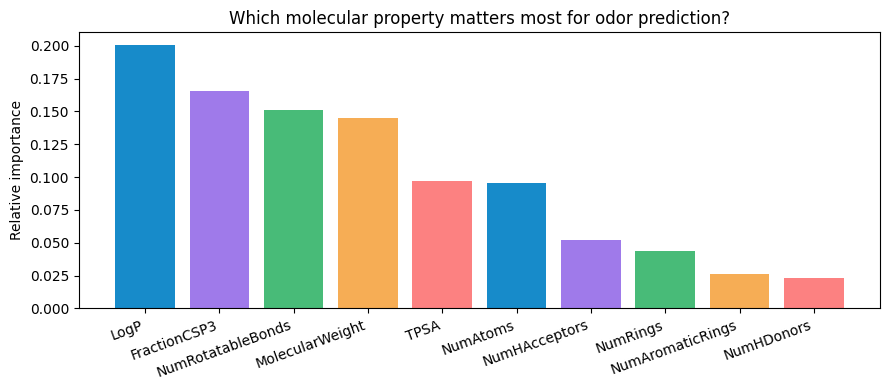

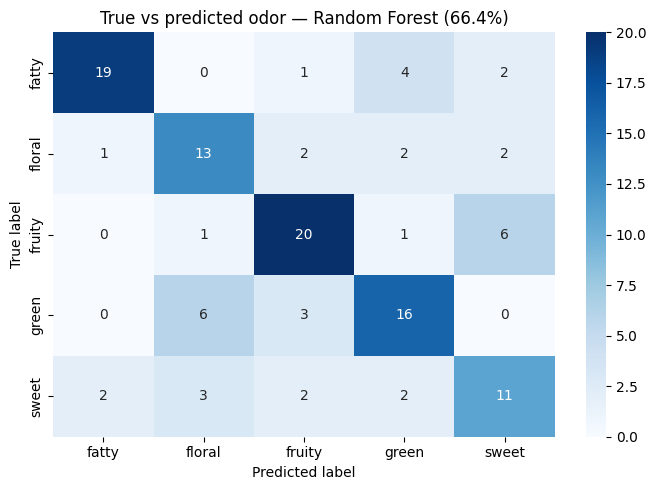

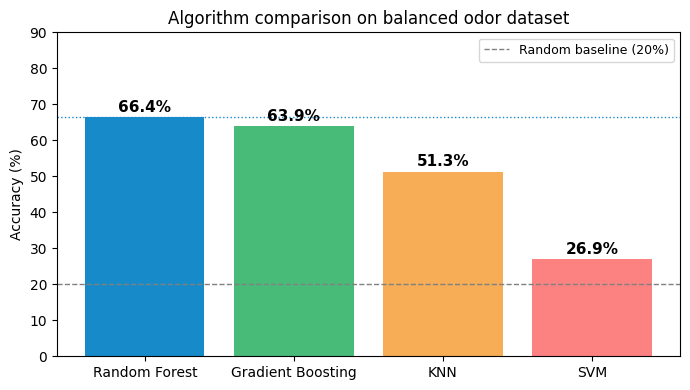

3 images saved and ready for the article


In [10]:
# ── Image 1: Feature importance ───────────────────────────────────────────
importances = best_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 4))
plt.bar(
    [feature_cols[i] for i in sorted_idx],
    [importances[i]  for i in sorted_idx],
    color=['#178BCA','#9F7AEA','#48BB78','#F6AD55','#FC8181',
           '#178BCA','#9F7AEA','#48BB78','#F6AD55','#FC8181']
)
plt.title('Which molecular property matters most for odor prediction?')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Relative importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ── Image 2: Confusion matrix ─────────────────────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test)
cm     = confusion_matrix(y_test, y_pred)
le     = LabelEncoder().fit(df_balanced['label'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('True vs predicted odor — Random Forest (66.4%)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Image 3: Model comparison bar chart ───────────────────────────────────
model_names   = ['Random Forest', 'Gradient Boosting', 'KNN', 'SVM']
model_scores  = [66.4, 63.9, 51.3, 26.9]
bar_colors    = ['#178BCA', '#48BB78', '#F6AD55', '#FC8181']

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, model_scores, color=bar_colors)
plt.axhline(y=20, color='gray', linestyle='--', linewidth=1, label='Random baseline (20%)')
plt.axhline(y=66.4, color='#178BCA', linestyle=':', linewidth=1)
plt.ylabel('Accuracy (%)')
plt.title('Algorithm comparison on balanced odor dataset')
plt.ylim(0, 90)
plt.legend(fontsize=9)
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{score}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("3 images saved and ready for the article")

In [11]:
from google.colab import files

for fname in ['top_odors.png',
              'feature_importance.png',
              'confusion_matrix.png',
              'model_comparison.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>